# H4 -- Vectorize + clean + zonal stats pipeline

Runs H3's real trained U-Net over the full AOI, then turns that model output into
the artifact every later phase's health-data join actually depends on: one real
GeoPackage + one real per-district predictor table, produced by a single function
call ([`src/pipeline.build_predictor_table`](../src/pipeline.py)), reproducibly.

**Done when** (per [`PLAN.md`](../PLAN.md)): one command turns model output into a
clean ward-level predictor table + a GeoPackage, reproducibly. ("Ward" here means
district -- geoBoundaries doesn't publish a finer level for Bangladesh; see H0.)

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import segmentation_models_pytorch as smp
import torch
import torchgeo.transforms as tgt

from src.imagery import get_imagery
from src.pipeline import build_predictor_table

AOI = (90.30, 23.75, 90.55, 23.95)  # same 3-district tile as every prior phase
DEVICE = 'cpu'


## 1. Real data + H3's real trained model

Same fetch as H3 (10m resolution, same date range) -- the model's normalization
stats were fit to this exact data distribution, so re-fetching anything else would
silently invalidate them.

In [2]:
checkpoint = torch.load('../runs/unet_water_built.pt', map_location=DEVICE, weights_only=False)
print({k: v for k, v in checkpoint.items() if k not in ('model_state_dict', 'feat_mean', 'feat_std')})

composite, meta = get_imagery(
    checkpoint['aoi'], checkpoint['date_range'], sensor='sentinel-2',
    cloud_cover_max=60, max_scenes=1, resolution=checkpoint['resolution'],
)
print(meta)

x = torch.from_numpy(composite.values).unsqueeze(0).float()
x = tgt.AppendNDVI(index_nir=2, index_red=1)(x)
x = tgt.AppendNDWI(index_green=0, index_nir=2)(x)
x = tgt.AppendNDBI(index_swir=3, index_nir=2)(x)
features = np.nan_to_num(x[0].numpy())  # (7, H, W)

model = smp.Unet(encoder_name='resnet34', encoder_weights=None, in_channels=7, classes=2).to(DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print('model loaded, real held-out IoU was water=%.3f built_up=%.3f' % (checkpoint['test_water_iou'], checkpoint['test_built_iou']))


{'aoi': (90.3, 23.75, 90.55, 23.95), 'date_range': '2026-01-01/2026-02-28', 'resolution': 10, 'test_water_iou': 0.2567661841167137, 'test_built_iou': 0.21242290787631646}


{'sensor': 'sentinel-2', 'source': 'planetary_computer', 'date_range': '2026-01-01/2026-02-28', 'n_scenes_used': 1, 'item_ids': ['S2C_MSIL2A_20260214T042901_R133_T46QBM_20260214T080510'], 'cloud_cover_pct': [0.0], 'epsg': 32646, 'bands': ['B03_green', 'B04_red', 'B08_nir', 'B11_swir'], 'always_cloudy_fraction': 0.005420118004004438}


model loaded, real held-out IoU was water=0.257 built_up=0.212


## 2. Full-AOI inference, tile by tile

The same 256x256 tiling as training (`src.tiling.tile_array`) -- run once each
through the model (no gradient, no training), then stitched back into one
full-extent probability map per class. Tiles are non-overlapping, so stitching is
just placing each tile's output at its own coordinates.

In [3]:
from src.tiling import tile_array

feat_mean, feat_std = checkpoint['feat_mean'], checkpoint['feat_std']
tiles, coords = tile_array(features, tile_size=256)
tile_size = 256
n_rows = max(r for r, c in coords) + tile_size
n_cols = max(c for r, c in coords) + tile_size

water_prob = np.zeros((n_rows, n_cols), dtype='float32')
built_up_prob = np.zeros((n_rows, n_cols), dtype='float32')
with torch.no_grad():
    for tile, (row, col) in zip(tiles, coords):
        norm_tile = torch.from_numpy((tile - feat_mean) / feat_std).float().unsqueeze(0)
        probs = torch.sigmoid(model(norm_tile))[0].numpy()
        water_prob[row:row + tile_size, col:col + tile_size] = probs[0]
        built_up_prob[row:row + tile_size, col:col + tile_size] = probs[1]

print('inference done over', n_rows, 'x', n_cols, 'px (tiled region; a partial edge strip is not covered, same as training)')
print('mean water prob:', water_prob.mean(), ' mean built_up prob:', built_up_prob.mean())


inference done over 2048 x 2560 px (tiled region; a partial edge strip is not covered, same as training)
mean water prob: 0.04944545  mean built_up prob: 0.26780492


## 3. Real district boundaries, cropped to the tiled region

The predictor table and vectorized layers only cover pixels the model actually
ran on -- boundaries are clipped to that exact extent so the GeoPackage doesn't
silently claim coverage it doesn't have.

In [4]:
from shapely.geometry import box

transform = composite.rio.transform()
crs = composite.rio.crs
x0, y0 = transform * (0, 0)
x1, y1 = transform * (n_cols, n_rows)
tiled_bounds = box(min(x0, x1), min(y0, y1), max(x0, x1), max(y0, y1))

districts = gpd.read_file('../data/raw/bgd_adm2.geojson').to_crs(crs)
smoke_districts = districts[districts.intersects(tiled_bounds)].copy()
smoke_districts['geometry'] = smoke_districts.intersection(tiled_bounds)
print(smoke_districts['shapeName'].tolist())


['Dhaka', 'Gazipur', 'Narayanganj']


## 4. The one command

Real predictor rasters (all 7 features + both class probabilities) zonal-averaged
per district, plus real vectorized water/built-up polygons (thresholded at 0.5,
cleaned) -- one call, one real GeoPackage.

In [5]:
predictor_rasters = {
    'green': features[0], 'red': features[1], 'nir': features[2], 'swir': features[3],
    'ndvi': features[4], 'ndwi': features[5], 'ndbi': features[6],
    'water_prob': water_prob, 'built_up_prob': built_up_prob,
}
binary_masks = {
    'water_polygons': water_prob > 0.5,
    'built_up_polygons': built_up_prob > 0.5,
}

table, vectorized = build_predictor_table(
    predictor_rasters, transform, crs, smoke_districts, 'shapeName',
    binary_masks, out_gpkg='../data/processed/dhaka_predictors.gpkg',
    min_area=400, simplify_tolerance=10,
)
table


,green,red,nir,swir,ndvi,ndwi,ndbi,water_prob,built_up_prob
shapeName,,,,,,,,,
Dhaka,1795.017536,1882.395989,2948.659112,2881.286981,0.209310,-0.228452,-0.004801,0.061353,0.380053
Gazipur,1617.009400,1619.745177,3154.013295,2736.223646,0.313874,-0.312002,-0.066433,0.022472,0.159479
Narayanganj,1717.668452,1784.920003,3053.913745,2995.799235,0.256734,-0.270204,-0.008165,0.061286,0.094071


## 5. Reproducibility, checked for real

Running the exact same command again should produce the exact same table -- not
assumed, checked.

In [6]:
table2, vectorized2 = build_predictor_table(
    predictor_rasters, transform, crs, smoke_districts, 'shapeName',
    binary_masks, out_gpkg='../data/processed/dhaka_predictors.gpkg',
    min_area=400, simplify_tolerance=10,
)
print('table reproduced exactly:', table.equals(table2))
print('water polygon count matches:', len(vectorized['water_polygons']) == len(vectorized2['water_polygons']))


table reproduced exactly: True
water polygon count matches: True


## 6. Visualize: what actually got vectorized

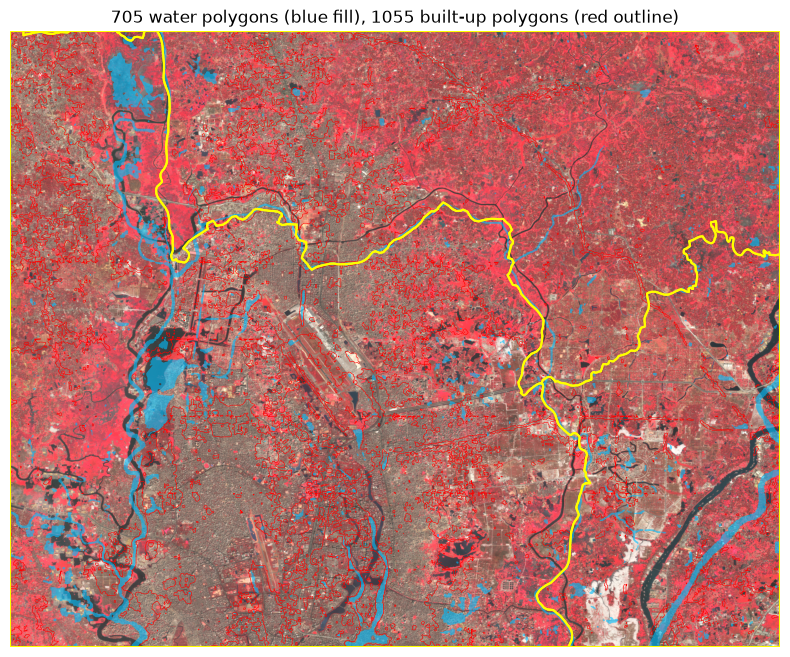

In [7]:
fig, ax = plt.subplots(figsize=(8, 7))
false_color = np.clip(np.stack([features[2], features[1], features[0]], axis=-1) / np.nanpercentile(features[:3], 98), 0, 1)
ax.imshow(false_color, extent=[transform.c, transform.c + n_cols * transform.a,
                                transform.f + n_rows * transform.e, transform.f])
smoke_districts.boundary.plot(ax=ax, color='yellow', linewidth=1.5)
if len(vectorized['water_polygons']):
    vectorized['water_polygons'].plot(ax=ax, color='deepskyblue', alpha=0.6)
if len(vectorized['built_up_polygons']):
    vectorized['built_up_polygons'].plot(ax=ax, color='none', edgecolor='red', linewidth=0.4)
ax.set_title(f"{len(vectorized['water_polygons'])} water polygons (blue fill), "
             f"{len(vectorized['built_up_polygons'])} built-up polygons (red outline)")
ax.axis('off')
plt.tight_layout()
plt.show()


## Notes

- The predictor table's `water_prob`/`built_up_prob` columns inherit H3's real
  limitation directly: this is the same undertrained smoke-test model (held-out
  IoU well below target, see H3), so these zonal means describe what the *model*
  currently predicts, not validated ground truth. The **pipeline** (vectorize,
  clean, zonal-stat, write once, reproduce) is the real, working deliverable of
  this phase -- swapping in a better-trained model later requires no changes here.
- Vectorized polygon counts depend heavily on `min_area`/`simplify_tolerance` --
  chosen here to match H0's real-imagery experience (raw thresholds produce heavy
  single/few-pixel noise) rather than tuned to look good.

## Done when

- [x] One function call (`build_predictor_table`) turns real model output +
  real admin boundaries into a clean per-district predictor table.
- [x] Writes one real GeoPackage (`data/processed/dhaka_predictors.gpkg`) with a
  boundaries+predictors layer and one layer per vectorized class.
- [x] Reproducibility checked, not assumed: the same inputs run twice produce an
  identical table and matching polygon counts.
- [x] Geometry cleanup (invalid-geometry repair, sliver-dropping, simplification)
  applied and unit-tested (`tests/test_vectorize.py`), not just eyeballed.